# Predicción de Abandono de Clientes (Churn Prediction) usando Machine Learning

## Descripción

Este proyecto tiene como objetivo desarrollar modelos de machine learning para predecir el abandono de clientes en una empresa de telecomunicaciones. A través de análisis exploratorio de datos (EDA), preprocesamiento y modelado (Regresión Logística y Random Forest), se identifican los factores clave que influyen en el churn y se proponen estrategias de retención basadas en los resultados obtenidos.

# FASE 1: CARGA DE DATOS

In [1]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. SUBIR ARCHIVO DESDE MI PC
from google.colab import files
uploaded = files.upload()

# 3. CARGA DEL DATASET
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 4. VERIFICAR CARGA
print("Dimensiones del dataset:", df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dimensiones del dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 5. INFORMACIÓN GENERAL
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# 6. DESCRIPCIÓN ESTADÍSTICA
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#FASE 2: EDA

PASO 1: ENTENDER LA ESTRUCTURA

In [4]:
# 1. VER COLUMNAS
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# 2. VER TIPOS DE DATOS
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
# 3. VER VALORES NULOS
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


PASO 2: LIMPIEZA INICIAL

Problema típico en este dataset: TotalCharges suele estar como texto

In [7]:
# 1. CONVERTIR TotalCharges A NUMERICO
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# revisar nulos otra vez
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
#Eliminar nulos
df = df.dropna()

PASO 3: VARIABLE OBJETIVO (CHURN)

Pregunta clave: ¿Está balanceado el dataset?

Del grafico y las proporciones obtenidas (No:	0.734215 , Yes	0.265785) se observa que el dataset no esta balanceado ya que hay una mayor cantidad de clientes que No abandonarian a la empresa que los que si lo harian.


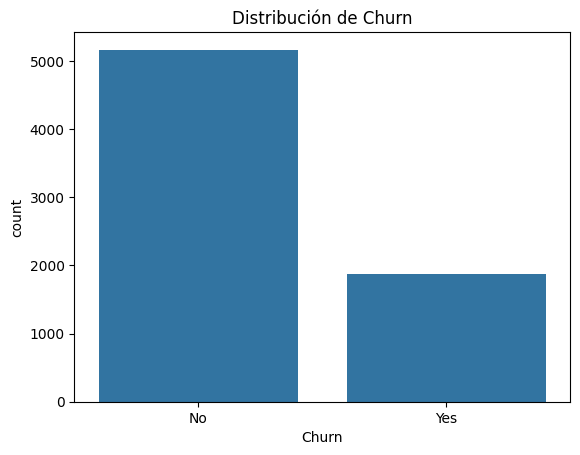

,proportion
Churn,
No,0.734215
Yes,0.265785


In [10]:
sns.countplot(x='Churn', data=df)
plt.title("Distribución de Churn")
plt.show()

# proporción
df['Churn'].value_counts(normalize=True)

PASO 4: ANÁLISIS DE VARIABLES CATEGÓRICAS

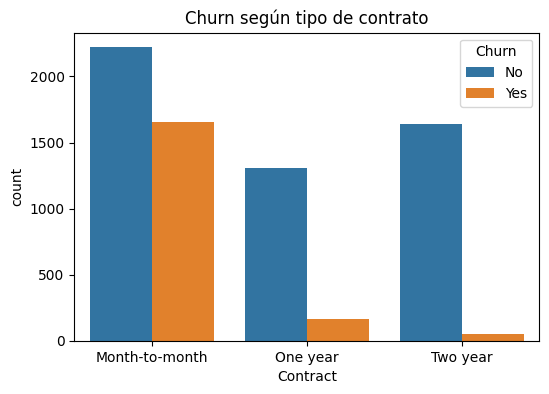

In [11]:
#Analisis del churn segun tipo de contrato
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn según tipo de contrato")
plt.show()

Los clientes con contrato mes a mes son los que más se dan de baja, con una cantidad de churn ("Yes") casi comparable a los que se quedan ("No"). En cambio, a medida que el contrato es más largo (1 año o 2 años), el churn cae drásticamente. Esto sugiere que el tipo de contrato es una variable muy relevante para predecir el churn, y que fidelizar a los clientes con contratos de mayor duración sería una estrategia clave para reducir la tasa de abandono.

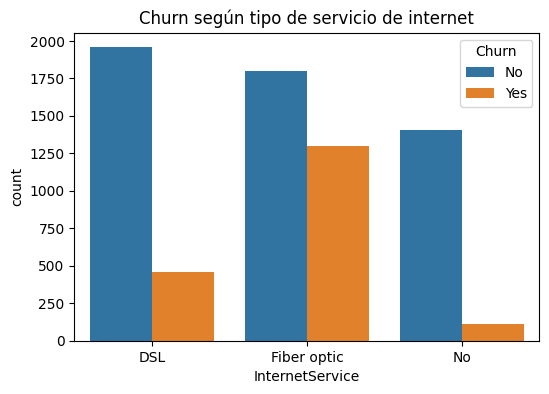

In [12]:
#Analisis del Churn según tipo de servicio de internet
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn según tipo de servicio de internet")
plt.show()

Los clientes con Fiber optic son los que presentan mayor churn, con una proporción de abandono notablemente alta respecto a los que se quedan. Esto podría deberse a que es un servicio más caro y los clientes esperan mayor calidad, por lo que cualquier insatisfacción los impulsa a irse. Los clientes con DSL tienen un churn mucho menor en términos relativos, y quienes no tienen servicio de internet casi no se dan de baja. Esto sugiere que el tipo de servicio de internet, especialmente la fibra óptica, es otro factor relevante para predecir el churn, y que vale la pena investigar si el precio o la calidad del servicio están detrás de esta insatisfacción.

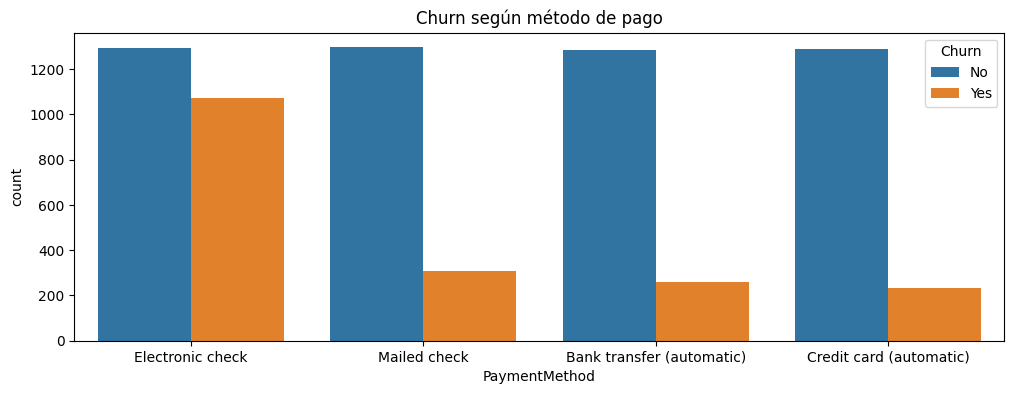

In [13]:
#Analisis del Churn según método de pago
plt.figure(figsize=(12,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn según método de pago")
plt.show()

Los clientes que pagan con Electronic check destacan notablemente con el mayor churn de todos los métodos, con una barra naranja muy superior a la de los demás. En cambio, los pagos automáticos como Bank transfer y Credit card presentan un churn mucho más bajo, lo que sugiere que los clientes con pagos automatizados tienen mayor estabilidad y compromiso con el servicio. El Mailed check se ubica en un punto intermedio. Esto indica que el método de pago es un predictor relevante del churn, y que los clientes que no tienen pagos automatizados, especialmente los de cheque electrónico, tienen mayor probabilidad de abandonar el servicio.

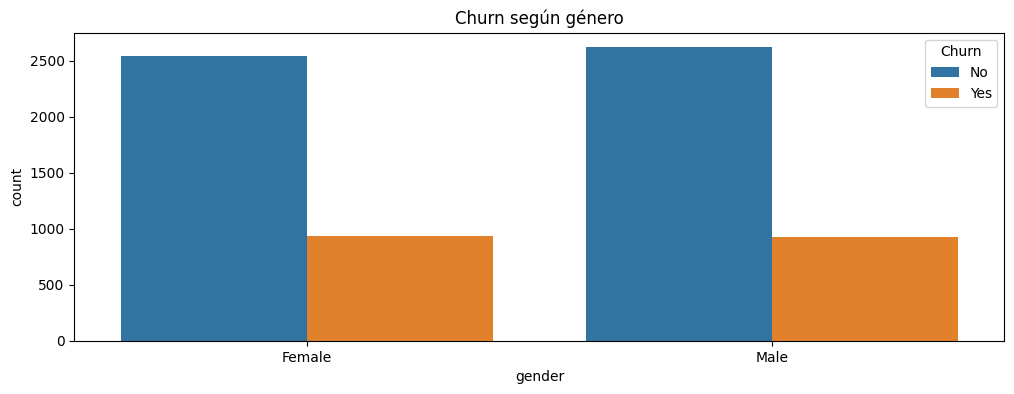

In [14]:
#Analisis del Churn según género
plt.figure(figsize=(12,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn según género")
plt.show()

El género prácticamente no influye en el churn. Tanto hombres como mujeres tienen una distribución casi idéntica entre los que se quedan y los que se dan de baja. Esto es indicio de que el género es una variable poco relevante para predecir el churn y no aportará mucho poder predictivo al modelo.

PASO 5: VARIABLES NUMERICAS

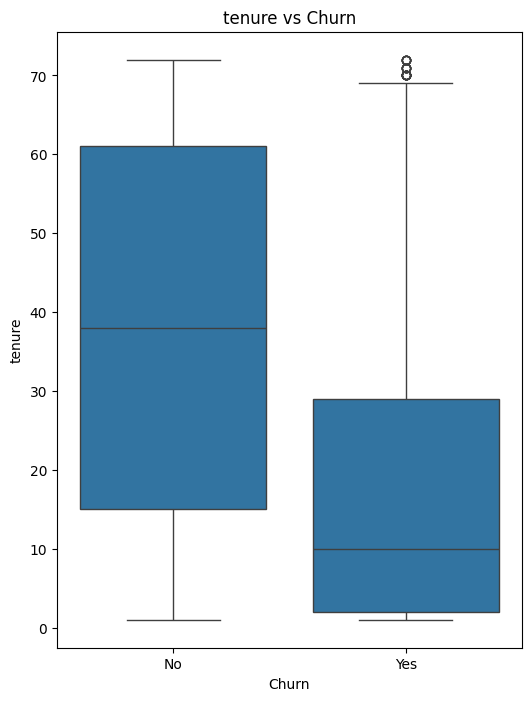

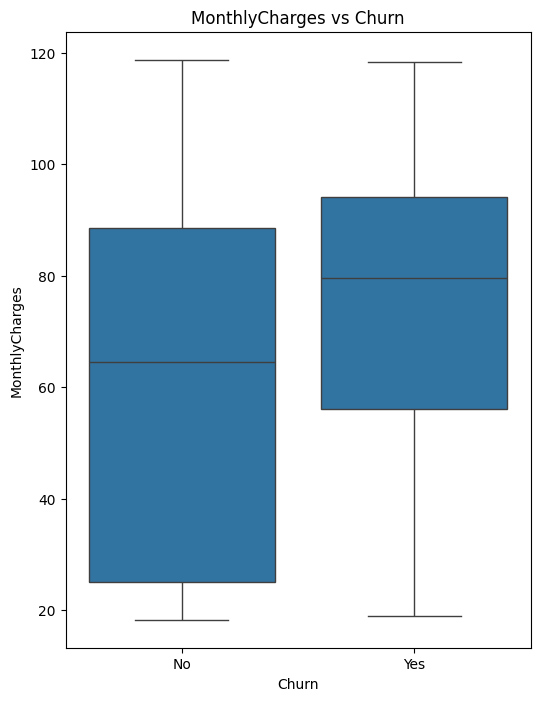

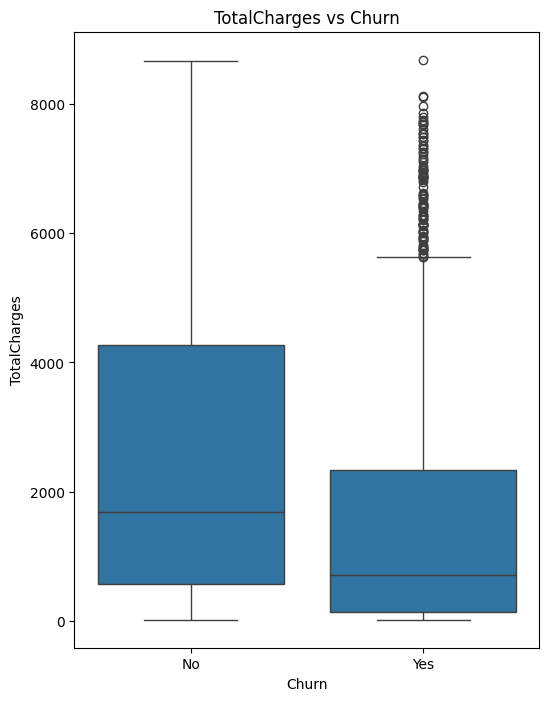

In [15]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(6,8))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

## Tenure vs Churn
Los clientes que se quedan tienen una mediana de permanencia alrededor de 38 meses, mientras que los que se dan de baja tienen una mediana de apenas 10 meses. Esto nos dice que la mayoría de clientes que abandona el servicio lo hace en los primeros meses y que a mayor antigüedad, menor probabilidad de churn, lo que convierte al tenure en una de las variables más predictivas del modelo.

## MonthlyCharges vs Churn
Los clientes que se dan de baja tienen cargos mensuales notablemente más altos, con una mediana cercana a 80, frente a unos $65 de los que se quedan. Esto refuerza la hipótesis de que el precio es un factor determinante en la decisión de abandonar el servicio, posiblemente relacionado con el servicio de fibra óptica que de acuerdo al contexto, es más caro.

## TotalCharges vs Churn
Aqui surge algo curioso, los clientes que se dan de baja tienen TotalCharges más bajos (mediana ~700) que los que se quedan (mediana ~$1700). Esto parece contradictorio, pero tiene sentido ya que es consecuencia directa del tenure bajo, es decir, si el cliente lleva poco tiempo, naturalmente ha pagado poco en total. Hay además varios outliers en el grupo de churn, que representan clientes con alto gasto total que igualmente se fueron, probablemente por insatisfacción con el precio mensual.

PASO 6: CORRELACION

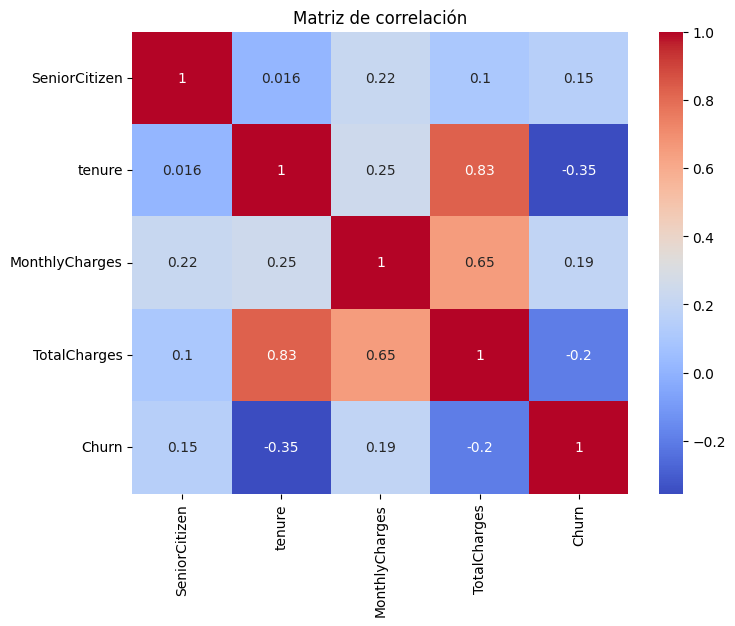

In [16]:
# CONVERTIR CHURN A NUMERICO
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# CORRELACION
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

# PASO 7: INSIGHTS

### Análisis de la Matriz de Correlación

Variables más relevantes para predecir el Churn:

Tenure → Churn: -0.35 (la más fuerte)

Correlación negativa moderada. A mayor antigüedad del cliente, menor probabilidad de que se dé de baja. Es la variable numérica más predictiva del modelo.

MonthlyCharges → Churn: 0.19

Correlación positiva leve. A mayores cargos mensuales, ligeramente mayor probabilidad de churn. Consistente con lo que vimos en el boxplot.

TotalCharges → Churn: -0.20

Correlación negativa leve. Como se explicó antes, es una consecuencia del tenure bajo.

SeniorCitizen → Churn: 0.15
Correlación positiva pero débil. Los adultos mayores tienen una leve tendencia mayor a irse.

###Multicolinealidad detectada
Tenure y TotalCharges: 0.83 → Correlación muy alta.

Tiene sentido: más tiempo = más pagos acumulados. Esto puede ser problemático en modelos como la regresión logística, donde la multicolinealidad infla los coeficientes. Podrías considerar eliminar TotalCharges del modelo.

MonthlyCharges y TotalCharges: 0.65 → También considerable, por la misma razón.

**Conclusión general:**

Las variables numéricas más útiles para el modelo son tenure y MonthlyCharges. TotalCharges es básicamente redundante dado que está fuertemente explicada por las otras dos.

#FASE 3: PREPROCESAMIENTO

PASO 1: ELIMINAR COLUMNAS INÚTILES

In [17]:
df = df.drop('customerID', axis=1)    #NO APORTA VALOR PREDICTIVO

PASO 2: SEPARAR VARIABLES

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

PASO 3: IDENTIFICAR TIPOS

In [19]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

PASO 4: ENCODING (VARIABLES CATEGÓRICAS)

In [20]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)      # CONVIERTE TEXTO -> NUMEROS

PASO 5: ESCALADO

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

PASO 6: TRAIN - TEST SPLIT

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
print("Train shape:", X_train.shape)


Train shape: (5625, 30)


In [24]:
print("Test shape:", X_test.shape)

Test shape: (1407, 30)


IMPORTANCIA DEL ESCALAMIENTO:

Los algoritmos de machine learning calculan distancias o pesos entre variables, por lo que si una variable tiene valores entre 0 y 72 (tenure) y otra entre 0 y 8000 (TotalCharges), el modelo le dará automáticamente más importancia a la de mayor magnitud, sin que eso signifique que sea más relevante. Escalar lleva todas las variables a la misma escala, garantizando que el modelo las trate de forma justa.

IMPORTANCIA DE LA SEPARACION DE DATOS EN TRAINING Y TEST:

Si entrenamos y evaluamos el modelo con los mismos datos, el modelo simplemente memoriza las respuestas y aparenta tener un rendimiento perfecto, pero fallará cuando enfrente datos nuevos. Separar los datos en entrenamiento y prueba nos permite simular un escenario real, evaluando qué tan bien generaliza el modelo a datos que nunca ha visto.

IMPORTANCIA DEL ENCODING

Los algoritmos de machine learning son esencialmente operaciones matemáticas, y las matemáticas no pueden operar sobre texto como "Male", "Female" o "Month-to-month". El encoding convierte estas categorías en números (0s y 1s), permitiendo que el modelo pueda procesarlas e incorporarlas al aprendizaje sin perder la información que contienen.

# FASE 4: MODELADO

PASO 1: REGRESIÓN LOGÍSTICA (BASELINE)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# modelo
log_model = LogisticRegression(max_iter=1000)

# entrenamiento
log_model.fit(X_train, y_train)

# predicciones
y_pred_log = log_model.predict(X_test)

# probabilidades
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [26]:
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

=== Logistic Regression ===
[[915 118]
 [181 193]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8319390591755491


# Matriz de Confusión

[[915  118]

 [181  193]]

915 → Clientes que no se fueron y el modelo predijo correctamente que no se irían

193 → Clientes que sí se fueron y el modelo predijo correctamente que se irían

118 → Falsos Positivos: el modelo dijo que se irían pero no lo hicieron

181 → Falsos Negativos: el modelo dijo que se quedarían pero sí se fueron ⚠️

**Los falsos negativos son el error más costoso en churn**, porque son clientes que se van y la empresa no tomó acciones para retenerlos.

# Reporte de clasificacion

- Para la clase 0 (no churn):

    Precision 0.83 → De los que predijo que se quedaban, el 83% realmente se quedó

    Recall 0.89 → De todos los que realmente se quedaron, detectó el 89%

    F1-score 0.86 → Buen balance entre precision y recall

- Para la clase 1 (churn):

    Precision 0.62 → De los que predijo como churn, solo el 62% realmente se fue

    Recall 0.52 → De todos los que realmente se fueron, solo detectó el 52% ⚠️

    F1-score 0.56 → Rendimiento mediocre en la clase que más nos importa

Accuracy 0.79 → El modelo acierta el 79% de los casos en general, pero este número es engañoso porque el dataset está desbalanceado (hay muchos más 0 que 1).

ROC-AUC: 0.83
Es la métrica más confiable aquí. Indica que el modelo tiene un 83% de probabilidad de distinguir correctamente entre un cliente que se va y uno que se queda. Un valor de 0.83 es considerado bueno, especialmente para un modelo baseline.

**Conclusión general:**

El modelo funciona bien para identificar a los que no se van, pero tiene dificultades con los que sí se van (recall de 0.52). Esto es típico cuando el dataset está desbalanceado. Un modelo más avanzado como Random Forest o XGBoost, o técnicas de balanceo como SMOTE, podrían mejorar significativamente el recall de la clase 1.

PASO 2: RANDOM FOREST

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [28]:
print("=== Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
[[926 107]
 [196 178]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

ROC-AUC: 0.8160153439180831


# Matriz de Confusión

[[926  107]

[196  178]]

926 → Clientes que no se fueron y el modelo predijo correctamente

178 → Clientes que sí se fueron y el modelo predijo correctamente

107 → Falsos Positivos: predijo churn pero no ocurrió

196 → Falsos Negativos: predijo que se quedaban pero se fueron ⚠️


# Reporte de clasificacion

- Para la clase 0 (no churn):

    Precision 0.83 → Igual que regresión logística

    Recall 0.90 → Mejoró ligeramente (0.89 → 0.90)
    
    F1-score 0.86 → Igual que regresión logística

- Para la clase 1 (churn):

    Precision 0.62 → Igual que regresión logística
    
    Recall 0.48 → Empeoró respecto a regresión logística (0.52 → 0.48) ⚠️
    
    F1-score 0.54 → Ligeramente peor (0.56 → 0.54)

Accuracy 0.78 → Prácticamente igual (0.79 → 0.78)

ROC-AUC: 0.816

Bajó ligeramente respecto a la regresión logística (0.83 → 0.816).

**Conclusión:**

La regresión logística superó al Random Forest en las métricas más importantes para este problema:

| Métrica | Logistic Regression | Random Forest |
|---|---|---|
| Recall clase 1 | **0.52** ✅ | 0.48 |
| ROC-AUC | **0.83** ✅ | 0.816 |
| Accuracy | **0.79** ✅ | 0.78 |

Esto puede deberse a que el dataset está desbalanceado (hay muchos más 0 que 1) y Random Forest con sus parámetros por defecto tiende a favorecer la clase mayoritaria. Técnicas como SMOTE, ajustar el parámetro class_weight='balanced', o probar XGBoost podrían revertir esto y sacarle más provecho al Random Forest.

PASO 3: COMPARACIÓN DE MODELOS

- ¿Cuál tiene mejor recall?

    La Regresión Logística con 0.52 vs 0.48 de Random Forest.
    Esto ocurre porque la regresión logística, al ser un modelo lineal, encuentra una frontera de decisión más general que no se ajusta tanto a los patrones de la clase mayoritaria. Random Forest con sus parámetros por defecto construye árboles que tienden a favorecer la clase con más ejemplos (no churn = 73% del dataset), lo que lo hace más conservador a la hora de predecir churn y por tanto detecta menos verdaderos positivos.

- ¿Cuál detecta mejor el churn?

    La Regresión Logística, y la razón es la misma: el desbalance del dataset. Cuando hay muchos más ejemplos de una clase que de otra, los modelos complejos como Random Forest aprenden muy bien la clase mayoritaria pero sacrifican la minoritaria. La regresión logística es menos susceptible a esto porque su frontera de decisión es más simple y no tiene la misma tendencia a "especializarse" en la clase dominante. Paradójicamente, en este caso la simplicidad gana.

- ¿Cuál tiene mejor ROC-AUC?

    La Regresión Logística con 0.83 vs 0.816 de Random Forest.
    El ROC-AUC evalúa qué tan bien el modelo separa probabilísticamente las dos clases a lo largo de todos los umbrales posibles. La regresión logística produce probabilidades mejor calibradas, es decir, cuando dice que un cliente tiene 80% de probabilidad de churn, ese número refleja mejor la realidad. Random Forest tiende a producir probabilidades más extremas (cercanas a 0 o a 1) porque se basan en votación de árboles, lo que puede perjudicar el AUC. Nuevamente, el desbalance del dataset amplifica esta diferencia.

### ¿Por qué es más importante el Recall que la Accuracy en Churn?

**El costo asimétrico de los errores:**

En churn, los dos tipos de error no tienen el mismo costo de negocio:

Falso Negativo → El modelo dice que el cliente se queda, pero en realidad se va.
El costo es altísimo pues la empresa no toma ninguna acción, el cliente se va, y se pierde todo el ingreso futuro que ese cliente hubiera generado. Adquirir un cliente nuevo cuesta entre 5 y 7 veces más que retener uno existente.

Falso Positivo → El modelo dice que el cliente se va, pero en realidad se queda.
El costo es bajo: la empresa le ofrece una promoción o descuento innecesariamente a un cliente que no iba a irse. Se pierde algo de dinero en la promoción, pero no se pierde el cliente.

**¿Por qué la Accuracy engaña?**

Imagina un modelo que siempre predice "no churn". Tendría una accuracy del 73% simplemente porque el 73% de los clientes realmente no se va. Pero su recall de churn sería 0%, es decir, no detectaría ni un solo cliente que se vaya. Un modelo así sería completamente inútil para el negocio pero estadísticamente "aceptable" en accuracy.

**La lógica de negocio:**

El objetivo real no es acertar el máximo de predicciones, sino identificar a todos los clientes en riesgo para actuar antes de que se vayan. Es preferible contactar a 100 clientes aunque solo 60 realmente fueran a irse, que dejar escapar a 40 clientes sin hacer nada. Los 40 falsos positivos solo cuestan una promoción; los 40 falsos negativos cuestan clientes perdidos para siempre.

PASO 4: CURVA ROC (PRO)

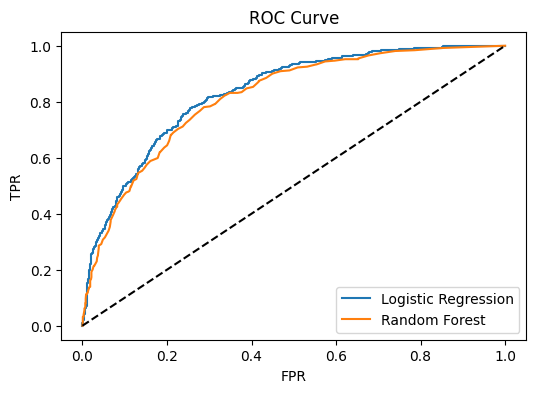

In [29]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

Cada punto de la curva representa un umbral de decisión distinto. Por defecto los modelos usan 0.5 (si probabilidad > 0.5 → predice churn), pero ese umbral se puede mover:

- Subir el umbral (más exigente para predecir churn) → menor TPR, menor FPR
- Bajar el umbral (menos exigente) → mayor TPR, pero también mayor FPR

Interpretación visual:

- **Esquina superior izquierda** → El punto ideal. TPR=1 y FPR=0, es decir, detecta todos los churns sin ningún falso positivo. Cuanto más se acerque la curva a esa esquina, mejor el modelo.
- **La diagonal punteada** → Modelo inútil. Un AUC de 0.5 significa que el modelo no distingue mejor que el azar.
- **El área bajo la curva (AUC)** → Cuanto mayor el área, mejor el modelo separa las dos clases.

Comparación entre modelos

- La curva azul (Regresión Logística) está ligeramente por encima de la naranja (Random Forest) en la zona izquierda del gráfico, que es la más importante. La zona izquierda representa umbrales altos, donde el modelo es muy selectivo para predecir churn. Que la regresión logística sea mejor ahí confirma lo que vimos en el AUC: 0.83 vs 0.816.

- Ambas curvas se juntan hacia la derecha porque a umbrales muy bajos cualquier modelo predice casi todo como churn y el TPR sube inevitablemente junto con el FPR.

**Conclusión**

La curva ROC confirma visualmente lo que ya sabíamos: la Regresión Logística es ligeramente mejor como modelo baseline en este problema, y ambos modelos están muy por encima de la diagonal, lo que indica que ambos tienen poder predictivo real.

PASO 5: INTERPRETACIÓN

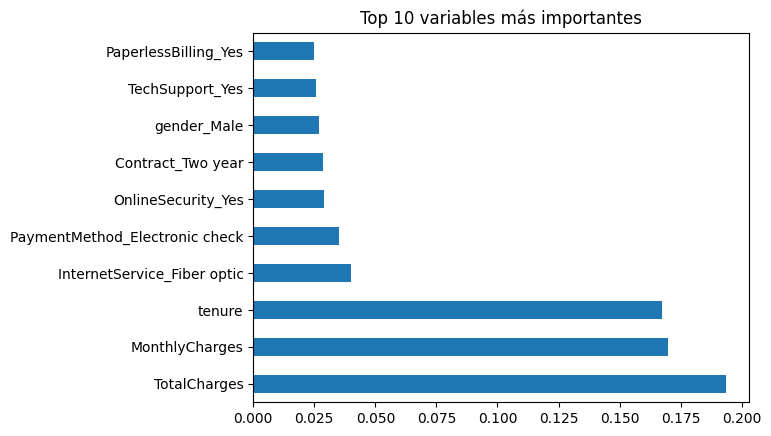

In [30]:
# Feature Importance (Random Forest)

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 variables más importantes")
plt.show()

**Variables que más influyen en el Churn:**

Las tres variables numéricas dominan completamente: TotalCharges (0.19), MonthlyCharges (0.17) y tenure (0.165) se separan por mucho del resto. Esto confirma que el comportamiento económico y la antigüedad del cliente son los factores más determinantes para predecir si se va o se queda. A mayor distancia con las demás variables, más concentrado está el poder predictivo en estas tres. Le siguen a distancia InternetService_Fiber optic y PaymentMethod_Electronic check, que aunque con importancia menor (~0.035), son consistentes con lo que encontramos en el análisis exploratorio. El resto de variables como género, soporte técnico o facturación sin papel tienen una importancia mínima y prácticamente no aportan al modelo.

**Qué tipo de clientes tienen mayor riesgo:**

El perfil de cliente de alto riesgo que emerge del modelo es: un cliente reciente (tenure bajo), con cargos mensuales altos, que usa fibra óptica como servicio de internet, paga con cheque electrónico y tiene contrato mes a mes. Este cliente concentra todas las señales de riesgo identificadas tanto en el EDA como en el modelo. En contraste, un cliente con varios años de antigüedad, contrato de dos años y pago automático tiene un perfil de muy bajo riesgo independientemente de otros factores.

**Decisiones a tomar:**

- Retención temprana: Los primeros meses son críticos. Se debería implementar un programa de onboarding agresivo para clientes nuevos, ya que el riesgo de churn es máximo en ese período.

- Migración de contratos: Incentivar a los clientes mes a mes a migrar a contratos anuales o bianuales mediante descuentos o beneficios exclusivos, dado que el tipo de contrato es un factor protector claro.

- Revisión de precios en fibra óptica: Los clientes de fibra óptica tienen mayor churn y mayores cargos mensuales, lo que sugiere que podrían percibir el servicio como caro en relación a lo que reciben. Una revisión de precios o mejora de calidad sería prioritaria.

- Automatización de pagos: Ofrecer incentivos para que los clientes que pagan con cheque electrónico migren a pagos automáticos, ya que ese método está asociado a mayor churn.

- Ignorar el género: Como variable, no aporta valor predictivo real y puede eliminarse del modelo para simplificarlo sin perder rendimiento.